# Burnout Prediction
A model to predict the burnout level of developers by analysing a set of key factors like 
* age: Developer age
* experience_years: Years of experience
* daily_work_hours: Work hours per day
* sleep_hours: Sleep duration
* caffeine_intake: Cups per day
* bugs_per_day: Bugs produced
* commits_per_day: Git commits
* meetings_per_day: Meetings attended
* screen_time: Total screen time
* exercise_hours: Physical activity
* stress_level: Stress score (0–100)
* burnout_level: Target variable

In [1]:
import pandas as pd

df = pd.read_csv("../../dataset/developer_burnout_dataset_7000.csv")
df.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   str    
dtypes: float64(11), str(1)
memory usage: 656.4 KB


In [3]:
df.isna().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

In [4]:
df = df.dropna(subset=['burnout_level'], axis=0)

In [5]:
df.isna().sum()

age                 139
experience_years    136
daily_work_hours    140
sleep_hours         137
caffeine_intake     137
bugs_per_day        137
commits_per_day     138
meetings_per_day    136
screen_time         138
exercise_hours      138
stress_level        138
burnout_level         0
dtype: int64

In [6]:
for col in df.columns:
    if col == 'burnout_level':
        continue
    df[col] = df[col].fillna(df[col].median())

df.isna().sum()

age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64

In [7]:
df['burnout_level'].unique()

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [8]:
df['burnout_level'] = df['burnout_level'].replace({"Medium": 1, 'Low': 0, 'High': 2}).astype(int)

df.info()

<class 'pandas.DataFrame'>
Index: 6860 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 696.7 KB


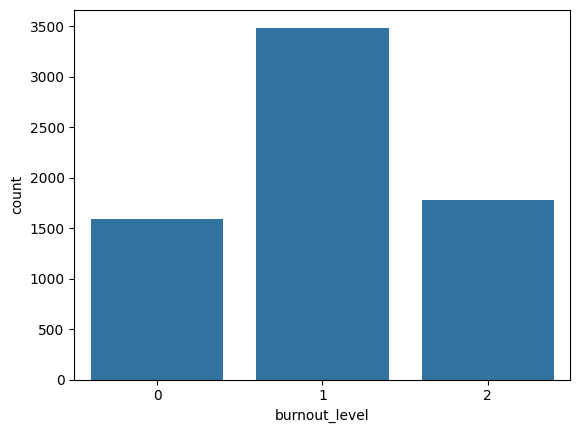

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='burnout_level')
plt.show()

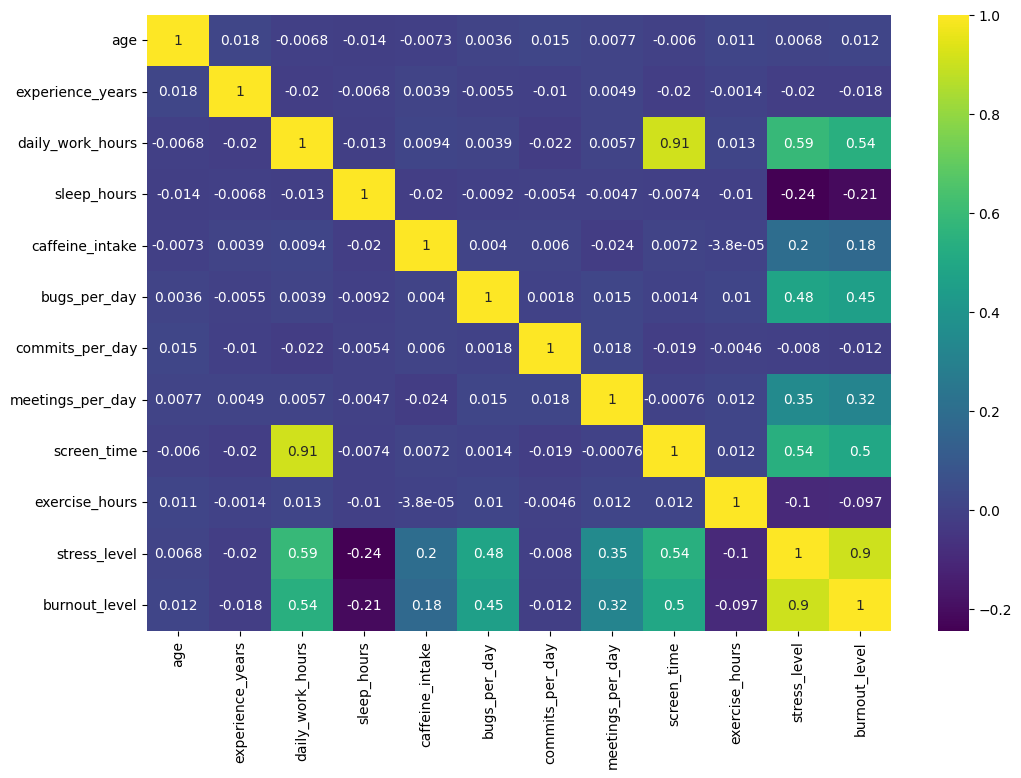

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='viridis')

plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

x=  df.drop('burnout_level', axis=1)
y = df['burnout_level']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)



In [12]:
model = LogisticRegression(max_iter=3000)
model.fit(x, y)

y_pred = model.predict(x_test)

y_pred[:5]

array([1, 1, 1, 1, 1])

In [13]:
model.score(x_test, y_test)

0.9628279883381924

<Axes: >

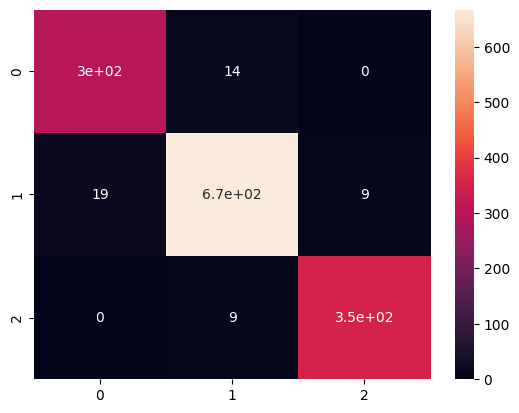

In [14]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       314
           1       0.97      0.96      0.96       695
           2       0.98      0.98      0.98       363

    accuracy                           0.96      1372
   macro avg       0.96      0.96      0.96      1372
weighted avg       0.96      0.96      0.96      1372



In [16]:
import pickle as pkl

with open('burnout.pkl', 'wb') as file:
    pkl.dump(model, file)